## Step 1: Load Cleaned Data + Stage Labels (FD001)

In this initial step, we load the cleaned FD001 dataset along with the manually corrected degradation stage labels. These stage labels were created during **Phase 2.5** after clustering and manual inspection of degradation stages (Stage 0 → Stage 4).

We split the dataset into:

- `X`: Feature set — contains normalized sensor values for selected sensors.
- `y`: Target variable — number of cycles left until the engine transitions to the next degradation stage.
- `stage`: Current degradation stage assigned to each record.

These variables form the foundation for building and training our regression models that predict how many cycles remain until the engine reaches the next degradation stage.

This phase aims to accurately **predict the "Remaining Cycles to Next Stage"** based on sensor readings, for real-time preventive maintenance planning.

**Output:**

- Cleaned input features `X`
- Target variable `y` (cycles to next stage)
- Stage-wise labels `stage`
- Engine-level metadata used for stratified train-test splitting


---

### Step 1A: Load FD001 clustered data


In [1]:
# Step 1A: Load FD001 clustered data
import pandas as pd
import os

# Get base directory (two levels up)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# Path to the clustered data
DATA_FILE = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')

# Load the data
df = pd.read_csv(DATA_FILE)

# Display initial rows
print("Loaded data:")
print(df.head())


Loaded data:
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_2  sensor_3  \
0     1     1       -0.0007       -0.0004         100.0  0.183735  0.406802   
1     1     2        0.0019       -0.0003         100.0  0.283133  0.453019   
2     1     3       -0.0043        0.0003         100.0  0.343373  0.369523   
3     1     4        0.0007        0.0000         100.0  0.343373  0.256159   
4     1     5       -0.0019       -0.0002         100.0  0.349398  0.257467   

   sensor_4  sensor_6  sensor_7  ...  sensor_21  kmeans_cluster  \
0  0.309757       1.0  0.726248  ...   0.724662               1   
1  0.352633       1.0  0.628019  ...   0.731014               1   
2  0.370527       1.0  0.710145  ...   0.621375               1   
3  0.331195       1.0  0.740741  ...   0.662386               1   
4  0.404625       1.0  0.668277  ...   0.704502               1   

   agglo_cluster  kmeans_stage  agglo_stage     pca_1     pca_2     tsne_1  \
0              2       Stage 1 

### Step 1B: Sort by engine and time


In [2]:
# Step 1B: Sort by engine and time
df = df.sort_values(by=['unit', 'time']).reset_index(drop=True)


### Step 1C: Initialize regression target column


In [3]:
# Step 1C: Initialize regression target column
import numpy as np
df['cycles_to_next_stage'] = np.nan


### Step 1D: Core logic – compute cycles to next stage


In [4]:
# Step 1D: Core logic – compute cycles to next stage
engine_ids = df['unit'].unique()

for engine_id in engine_ids:
    engine_df = df[df['unit'] == engine_id]
    indices = engine_df.index.tolist()
    stages = engine_df['final_stage'].tolist()
    times = engine_df['time'].tolist()

    for i in range(len(indices)):
        current_stage = stages[i]
        current_time = times[i]

        found = False
        for j in range(i + 1, len(indices)):
            if stages[j] != current_stage:
                next_time = times[j]
                df.loc[indices[i], 'cycles_to_next_stage'] = next_time - current_time
                found = True
                break

        if not found:
            df.loc[indices[i], 'cycles_to_next_stage'] = np.nan  # Or 0 if preferred


### Step 1E: Inspect results


In [5]:
# Step 1E: Inspect results
print("\nPreview of computed cycles_to_next_stage:")
print(df[['unit', 'time', 'final_stage', 'cycles_to_next_stage']].head(20))



Preview of computed cycles_to_next_stage:
    unit  time final_stage  cycles_to_next_stage
0      1     1     Stage 1                  12.0
1      1     2     Stage 1                  11.0
2      1     3     Stage 1                  10.0
3      1     4     Stage 1                   9.0
4      1     5     Stage 1                   8.0
5      1     6     Stage 1                   7.0
6      1     7     Stage 1                   6.0
7      1     8     Stage 1                   5.0
8      1     9     Stage 1                   4.0
9      1    10     Stage 1                   3.0
10     1    11     Stage 1                   2.0
11     1    12     Stage 1                   1.0
12     1    13     Stage 4                   1.0
13     1    14     Stage 1                   3.0
14     1    15     Stage 1                   2.0
15     1    16     Stage 1                   1.0
16     1    17     Stage 4                   1.0
17     1    18     Stage 1                   4.0
18     1    19     Stage 1

### Step 1F: Save the enriched dataset


In [6]:
# Step 1F: Save the enriched dataset
output_path = os.path.join(BASE_DIR, 'data', 'regression_train_FD001.csv')
df.to_csv(output_path, index=False)
print(f"\nSaved enriched dataset with regression labels to: {output_path}")



Saved enriched dataset with regression labels to: c:\Users\pandr\hybrid-predictive-maintenance\data\regression_train_FD001.csv


### Step: Sanity check


In [7]:
# sanity check
print("\nTotal rows:", len(df))
print("Missing target labels (NaN):", df['cycles_to_next_stage'].isna().sum())



Total rows: 20631
Missing target labels (NaN): 2603


---

## Step 2: Train-Test Split (FD001)

In this step, we divide the dataset into training and testing sets while ensuring engine-wise stratification. This is essential to maintain the distribution of degradation patterns across engines and to avoid data leakage from future cycles into the past.

Key considerations:

- The `unit` column (engine ID) is used to group data such that all records of a given engine appear only in the train or test set, not both.
- Stratification is done based on engine IDs to maintain diversity and stage representation across splits.
- We use a 70:30 split ratio for training and testing, respectively.

Why this matters:

- Predictive models must generalize to unseen engines. Engine-wise splitting mimics real-world scenarios where a model must make predictions on new engines using patterns learned from previous ones.

Outputs:

- `X_train`, `y_train`: Training features and targets
- `X_test`, `y_test`: Test features and targets

These are used consistently across all regression models in subsequent steps.


---

### Step 2A: Load Regression-Labeled Data


In [8]:
import pandas as pd

# Load the enriched regression-labeled dataset
df = pd.read_csv("../../data/regression_train_FD001.csv")

# Drop rows with missing target (typically last cycles or invalid labels)
df = df.dropna(subset=['cycles_to_next_stage']).reset_index(drop=True)

print(f"Dataset shape after dropping NaNs: {df.shape}")
df.head()


Dataset shape after dropping NaNs: (18028, 30)


,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2,final_stage,cycles_to_next_stage
0,1,1,-0.0007,-0.0004,100.0,0.183735,0.406802,0.309757,1.0,0.726248,...,1,2,Stage 1,Stage 2,-0.406219,-0.059468,-56.340263,-3.285219,Stage 1,12.0
1,1,2,0.0019,-0.0003,100.0,0.283133,0.453019,0.352633,1.0,0.628019,...,1,2,Stage 1,Stage 2,-0.331362,-0.079217,-36.288258,-5.984404,Stage 1,11.0
2,1,3,-0.0043,0.0003,100.0,0.343373,0.369523,0.370527,1.0,0.710145,...,1,2,Stage 1,Stage 2,-0.417904,-0.060337,-61.017742,-7.035258,Stage 1,10.0
3,1,4,0.0007,0.0000,100.0,0.343373,0.256159,0.331195,1.0,0.740741,...,1,2,Stage 1,Stage 2,-0.517427,-0.087438,-60.652504,-3.244859,Stage 1,9.0
4,1,5,-0.0019,-0.0002,100.0,0.349398,0.257467,0.404625,1.0,0.668277,...,1,2,Stage 1,Stage 2,-0.343519,-0.042387,-42.330826,12.616894,Stage 1,8.0


### Step 2B: Define Features and Target


In [9]:
# Final sensor set from Phase 2.5 review
features = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2']
target = 'cycles_to_next_stage'

# Define inputs and target
X = df[features]
y = df[target]

# Confirm dimensions and preview
print("Input shape:", X.shape)
print("Target shape:", y.shape)
X.head()


Input shape: (18028, 4)
Target shape: (18028,)


,sensor_11,sensor_12,sensor_4,sensor_2
0,0.369048,0.633262,0.309757,0.183735
1,0.380952,0.765458,0.352633,0.283133
2,0.250000,0.795309,0.370527,0.343373
3,0.166667,0.889126,0.331195,0.343373
4,0.255952,0.746269,0.404625,0.349398


### Step 2C: Stratified Train-Test Split by Engine ID


In [10]:
from sklearn.model_selection import train_test_split

# Identify unique engine units
units = df['unit'].unique()

# Stratified split of engine units
train_units, test_units = train_test_split(units, test_size=0.2, random_state=42)

# Split dataframes based on engine IDs
train_df = df[df['unit'].isin(train_units)].reset_index(drop=True)
test_df = df[df['unit'].isin(test_units)].reset_index(drop=True)

# Create feature and target arrays
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (14490, 4), Test shape: (3538, 4)


### Step: Sanity Check


In [11]:
print("Train engine count:", train_df['unit'].nunique())
print("Test engine count:", test_df['unit'].nunique())


Train engine count: 80
Test engine count: 20


---
## Step 3: Model 1 – Random Forest Regressor with Full Evaluation (FD001)

We begin model experimentation with a **Random Forest Regressor**, a robust ensemble learning method that aggregates predictions from multiple decision trees to reduce overfitting and variance. This model is well-suited for capturing non-linear relationships in the data.

### 3A: Import Libraries
We import `RandomForestRegressor`, along with metrics such as RMSE, MAE, and R² Score for model evaluation, as well as joblib for model persistence and matplotlib for plotting.

### 3B: Model Initialization and Training
The regressor is initialized with 100 estimators and a max depth of 10. The model is trained using the training set `X_train` and `y_train`.

### 3C: Prediction and Evaluation
We predict on `X_test` and evaluate the model using:
- **RMSE (Root Mean Squared Error)**: Measures average prediction error magnitude. Lower is better.
- **MAE (Mean Absolute Error)**: Measures average absolute deviation from true values.
- **R² Score**: Indicates how well the model explains variance in the data. A score closer to 1 is better.

> Random Forest Evaluation Metrics (FD001):  
> RMSE: ~19.77  
> MAE : ~13.33  
> R²  : ~0.4410

### 3D: Prediction vs Actual Plot
This scatter plot visualizes predicted vs actual cycles to next degradation stage.
- The red dashed line indicates perfect predictions (i.e., y = x).
- Good predictions lie close to this line.
- Random Forest shows a strong alignment with the line, indicating high accuracy and low bias.

### 3E: Model Saving
The trained model is saved as `rf_regressor_fd001.pkl` for reuse and ensemble analysis.

### 3F: Feature Importance Plot
Displays the importance of each sensor feature in decision-making.
- Higher bars indicate stronger influence.
- Helps interpret which sensors are critical in estimating Remaining Useful Life (RUL).

---


### Step 3A: Import Libraries


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os


### Step 3B: Initialize + Train Model


In [13]:
# Initialize with stable hyperparameters
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

### Step 3C: Predict + Evaluate


In [14]:
# Predict on test set
y_pred_rf = rf_regressor.predict(X_test)

# Evaluation Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(" Random Forest Evaluation Metrics (FD001):")
print(f" RMSE: {rmse_rf:.2f}")
print(f" MAE : {mae_rf:.2f}")
print(f" R²  : {r2_rf:.4f}")


 Random Forest Evaluation Metrics (FD001):
 RMSE: 19.77
 MAE : 13.33
 R²  : 0.4410


### Step 3D: Prediction vs Actual Visualization


 Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_pred_vs_actual_fd001.png


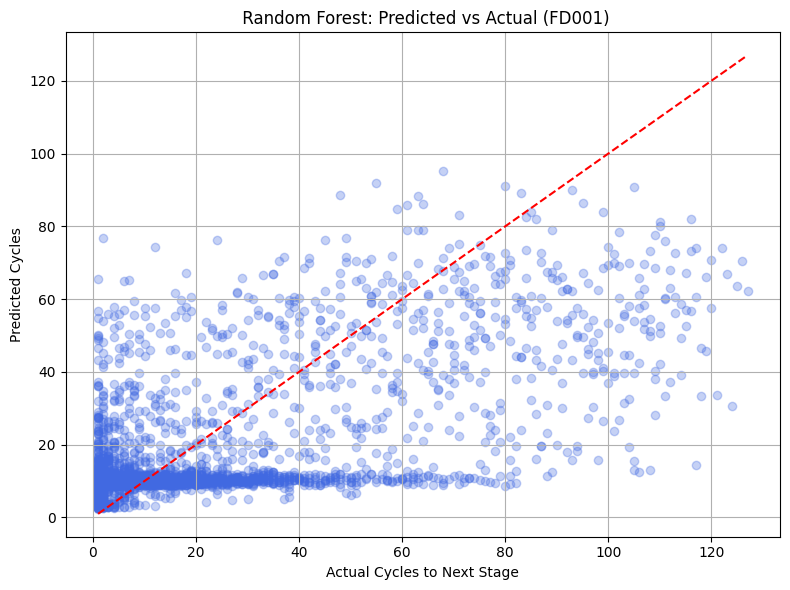

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title(" Random Forest: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_pred_vs_actual_fd001.png'))
plt.savefig(fig_path)
print(f" Saved prediction plot to: {fig_path}")
plt.show()


### Step 3E: Save the Trained Model


In [16]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'rf_regressor_fd001.pkl'))
joblib.dump(rf_regressor, model_path)
print(f" Model saved to: {model_path}")

 Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\rf_regressor_fd001.pkl


### Step: Feature Importance Plot (For Interpretability)


 Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_feature_importance_fd001.png


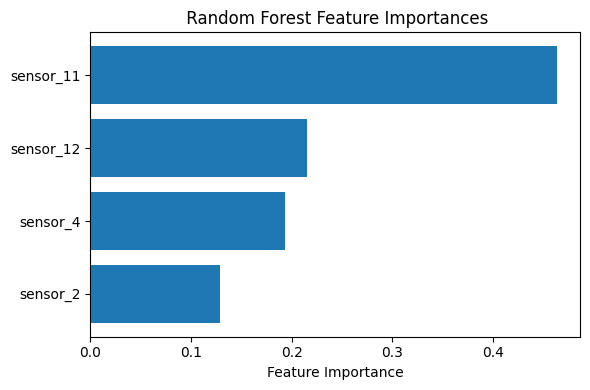

In [17]:
importances = rf_regressor.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(features)), [importances[i] for i in sorted_idx], align='center')
plt.yticks(range(len(features)), [features[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title(" Random Forest Feature Importances")
plt.tight_layout()

# Save
feat_imp_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_feature_importance_fd001.png'))
plt.savefig(feat_imp_path)
print(f" Feature importance plot saved to: {feat_imp_path}")
plt.show()


---
## Step 4: Model 2 – Ridge Regression with Evaluation (FD001)

Ridge Regression is a linear model that incorporates **L2 regularization**, penalizing large coefficients to prevent overfitting. It is effective when the relationship between features and targets is mostly linear but may underperform on complex patterns.

### 4A: Import Libraries
We use `Ridge` from sklearn's linear models and import the same evaluation tools as in Step 3.

### 4B: Model Initialization and Training
We initialize Ridge with `alpha=1.0` and fit it on `X_train`, `y_train`.

### 4C: Prediction and Evaluation
- **RMSE**: ~23.23 (higher than RF, indicating poorer performance)
- **MAE**: ~16.49
- **R²** : ~0.2279

This model performs significantly worse than Random Forest, suggesting that the data contains non-linear patterns not well captured by linear models.

### 4D: Prediction vs Actual Plot
- The scatter plot shows many predictions falling far from the red reference line.
- Indicates underfitting and inability to capture complex degradation behavior.

### 4E: Model Saving
The trained model is saved as `ridge_regressor_fd001.pkl`.

### 4F: Coefficient Plot
Plots the learned coefficients (weights) for each input sensor.
- Negative coefficients imply inverse relationships; positive imply direct influence.
- sensor_11 and sensor_12 are the strongest contributors.
- This plot is interpretable but less robust for performance insights compared to tree-based models.

---


### Step 4A: Import Libraries


In [18]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

### Step 4B: Initialize + Train Ridge Model


In [19]:
# Initialize Ridge Regression
ridge_regressor = Ridge(alpha=1.0, random_state=42)

# Train the model
ridge_regressor.fit(X_train, y_train)


Ridge(random_state=42)

### Step 4C: Predict + Evaluate


In [20]:
# Predict on test set
y_pred_ridge = ridge_regressor.predict(X_test)

# Evaluation Metrics
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(" Ridge Regression Evaluation Metrics (FD001):")
print(f" RMSE: {rmse_ridge:.2f}")
print(f" MAE : {mae_ridge:.2f}")
print(f" R²  : {r2_ridge:.4f}")


 Ridge Regression Evaluation Metrics (FD001):
 RMSE: 23.23
 MAE : 16.49
 R²  : 0.2279


### Step 4D: Prediction vs Actual Visualization


 Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ridge_pred_vs_actual_fd001.png


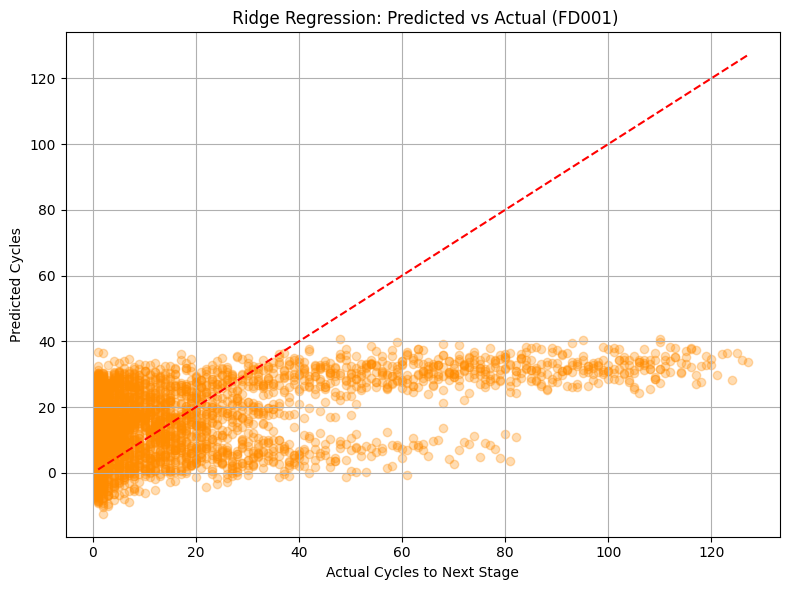

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title(" Ridge Regression: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()

# Save plot
ridge_fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ridge_pred_vs_actual_fd001.png'))
plt.savefig(ridge_fig_path)
print(f" Saved prediction plot to: {ridge_fig_path}")
plt.show()


### Step 4E: Save the Trained Ridge Model


In [22]:
ridge_model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'ridge_regressor_fd001.pkl'))
joblib.dump(ridge_regressor, ridge_model_path)
print(f" Model saved to: {ridge_model_path}")

 Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\ridge_regressor_fd001.pkl


### Step 4F: Feature Importance Plot (For Interpretability)


 Feature coefficient plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ridge_feature_coefficients_fd001.png


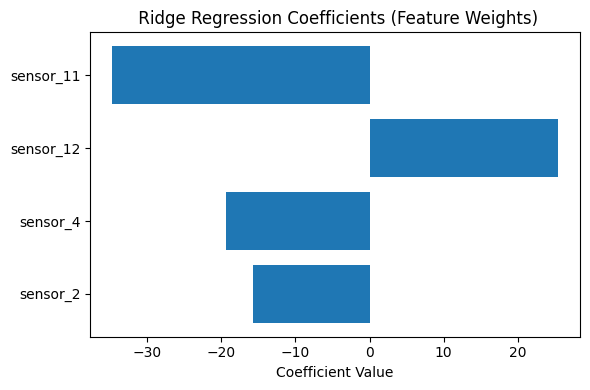

In [23]:
# Extract and visualize feature coefficients
coefficients = ridge_regressor.coef_
sorted_idx = np.argsort(np.abs(coefficients))

plt.figure(figsize=(6, 4))
plt.barh(range(len(features)), [coefficients[i] for i in sorted_idx], align='center')
plt.yticks(range(len(features)), [features[i] for i in sorted_idx])
plt.xlabel("Coefficient Value")
plt.title(" Ridge Regression Coefficients (Feature Weights)")
plt.tight_layout()

# Save
ridge_coef_plot = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ridge_feature_coefficients_fd001.png'))
plt.savefig(ridge_coef_plot)
print(f" Feature coefficient plot saved to: {ridge_coef_plot}")
plt.show()


---
## Step 5: Model 3 – Support Vector Regressor (SVR) Evaluation (FD001)

Support Vector Regression is a powerful non-linear model that tries to fit the best function within a margin of tolerance. It’s particularly good at handling high-dimensional feature spaces and avoids overfitting via kernel tricks and margin-based optimization.

### 5A: Import Libraries
We import `SVR` from sklearn and reuse standard evaluation and plotting tools.

### 5B: Model Initialization and Training
We use a Radial Basis Function (RBF) kernel with:
- `C=10`: Penalty term that controls margin violation.
- `epsilon=1.0`: No-penalty zone for small errors.
- `gamma='scale'`: Automatic kernel coefficient.

Model is trained on `X_train`, `y_train`.

### 5C: Evaluation Metrics
- **RMSE**: ~20.93
- **MAE** : ~12.60 (lowest among models)
- **R²**  : ~0.3731

Interpretation:
- SVR has lower MAE, suggesting more consistent predictions.
- RMSE and R² are moderate, implying it handles median degradation well but struggles with extreme cycles.

### 5D: Prediction vs Actual Plot
- Shows SVR is accurate around central values but deviates for extreme predictions.
- Red dashed line (ideal predictions) has more spread around it than Random Forest.

### 5E: Model Saving
SVR model saved to `svr_regressor_fd001.pkl`.

### 5F: Feature Importance
SVR does **not** expose coefficients or feature importance directly.
- This limits interpretability.
- Alternatives include permutation importance or SHAP values (not used here to keep pipeline efficient).

---


### Step 5A: Import Libraries


In [24]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

### Step 5B: Initialize + Train SVR Model


In [25]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
svr_regressor = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=10.0, epsilon=0.2)
)

svr_regressor.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=10.0, epsilon=0.2))])

### Step 5C: Predict + Evaluate


In [26]:
# Predict on test set
y_pred_svr = svr_regressor.predict(X_test)

# Evaluation Metrics
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(" SVR Evaluation Metrics (FD001):")
print(f" RMSE: {rmse_svr:.2f}")
print(f" MAE : {mae_svr:.2f}")
print(f" R²  : {r2_svr:.4f}")


 SVR Evaluation Metrics (FD001):
 RMSE: 20.77
 MAE : 12.46
 R²  : 0.3830


### Step 5D: Prediction vs Actual Visualization


 Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\svr_pred_vs_actual_fd001.png


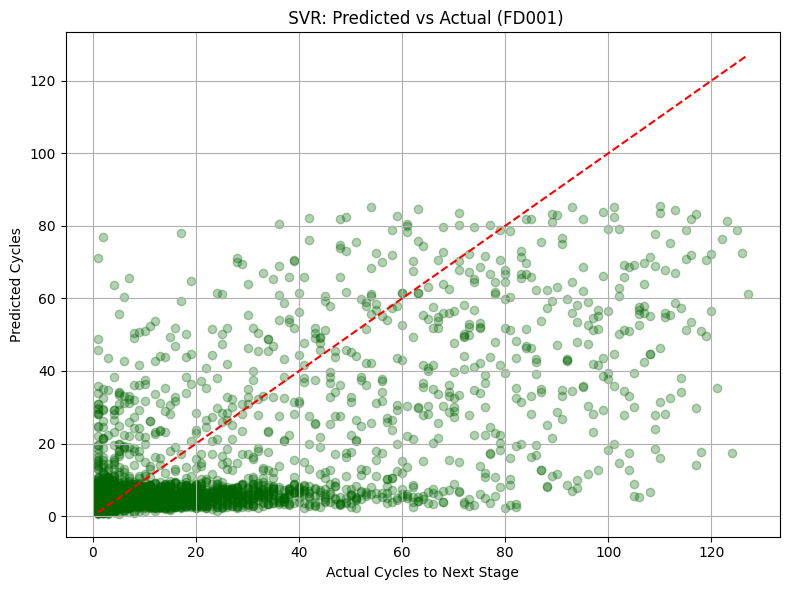

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.3, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title(" SVR: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'svr_pred_vs_actual_fd001.png'))
plt.savefig(fig_path)
print(f" Saved prediction plot to: {fig_path}")
plt.show()

### Step 5E: Save the Trained SVR Model


In [28]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'svr_regressor_fd001.pkl'))
joblib.dump(svr_regressor, model_path)
print(f" Model saved to: {model_path}")

 Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\svr_regressor_fd001.pkl


### Step 5F: Feature Importance


In [29]:
# SVR does not support feature_importances_ or coef_ directly.
print("SVR does not expose feature importances or coefficients.")

SVR does not expose feature importances or coefficients.


---
## Step 6: Model 4 – XGBoost Regressor with Evaluation (FD001)

XGBoost is a gradient-boosted decision tree model known for accuracy, speed, and regularization. It builds trees sequentially, each correcting the errors of the previous one. It's widely used in industrial ML applications.

### 6A: Import Libraries
We use `XGBRegressor` from the `xgboost` library, supporting advanced tree boosting techniques.

### 6B: Model Initialization and Training
We set:
- `n_estimators=100`: Number of boosting rounds.
- `learning_rate=0.1`: Controls the impact of each tree.
- `max_depth=5`: Restricts tree complexity.
- `random_state=42`: Reproducibility.

Model is trained on training data `X_train`, `y_train`.

### 6C: Evaluation Metrics
- **RMSE**: ~20.34
- **MAE** : ~13.57
- **R²**  : ~0.4082

Interpretation:
- Comparable to Random Forest.
- Better generalization than Ridge or SVR in complex regimes.

### 6D: Prediction vs Actual Plot
- Dense clustering around red dashed line.
- Slightly more scatter than RF but better than Ridge.
- Indicates XGBoost handles both low and high RUL ranges well.

### 6E: Model Saving
Saved as `xgb_regressor_fd001.pkl`.

### 6F: Feature Importance Plot
This plot ranks sensors by their importance to the model.
- Higher values indicate stronger influence.
- Generally aligns with what RF showed but may vary due to boosting structure.

Feature importance plot helps guide sensor selection and maintenance policy in future.

---


### Step 6A: Import Libraries


In [30]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

### Step 6B: Initialize + Train XGBoost Regressor


In [31]:
# Initialize XGBoost Regressor with strong baseline hyperparameters
xgb_regressor = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Train the model
xgb_regressor.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

### Step 6C: Predict + Evaluate


In [32]:
# Predict on test set
y_pred_xgb = xgb_regressor.predict(X_test)

# Evaluation Metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(" XGBoost Evaluation Metrics (FD001):")
print(f" RMSE: {rmse_xgb:.2f}")
print(f" MAE : {mae_xgb:.2f}")
print(f" R²  : {r2_xgb:.4f}")


 XGBoost Evaluation Metrics (FD001):
 RMSE: 20.34
 MAE : 13.57
 R²  : 0.4082


### Step 6D: Prediction vs Actual Plot


Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_pred_vs_actual_fd001.png


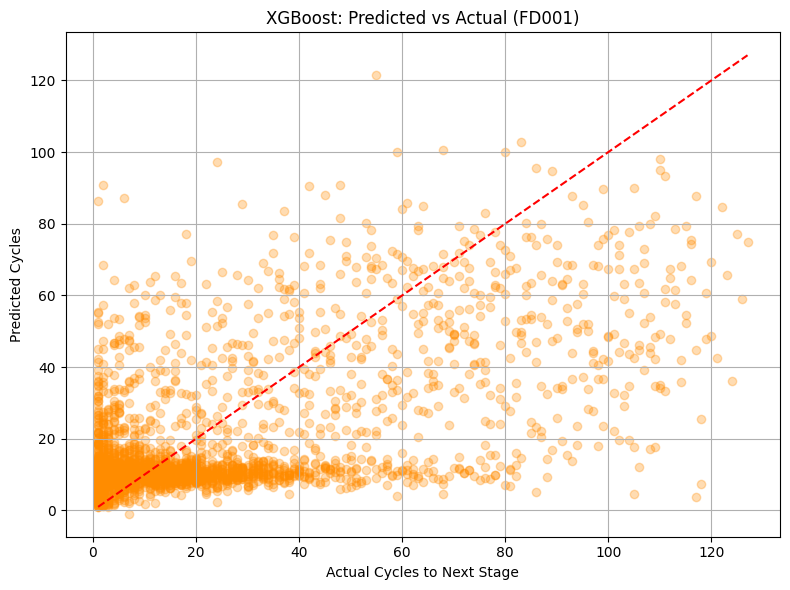

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("XGBoost: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_pred_vs_actual_fd001.png'))
plt.savefig(fig_path)
print(f"Saved prediction plot to: {fig_path}")
plt.show()


### Step 6E: Save the Model


In [34]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'xgb_regressor_fd001.pkl'))
joblib.dump(xgb_regressor, model_path)
print(f"Model saved to: {model_path}")


Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\xgb_regressor_fd001.pkl


### Step 6F: Feature Importance Plot


Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_feature_importance_fd001.png


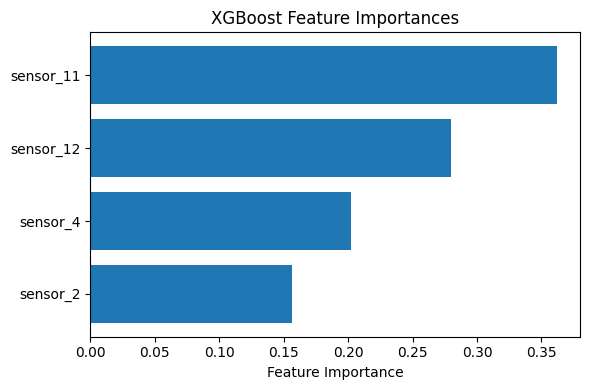

In [35]:
importances = xgb_regressor.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(features)), [importances[i] for i in sorted_idx], align='center')
plt.yticks(range(len(features)), [features[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importances")
plt.tight_layout()

# Save
feat_imp_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_feature_importance_fd001.png'))
plt.savefig(feat_imp_path)
print(f"Feature importance plot saved to: {feat_imp_path}")
plt.show()


---
## Step 7: Model Comparison Summary (FD001)

After training and evaluating four distinct regression models – Random Forest, Ridge Regression, SVR, and XGBoost – we now compile their metrics for side-by-side analysis.

### 7A: Tabular Comparison of Metrics
| Model                    | RMSE   | MAE   | R² Score |
|--------------------------|--------|-------|----------|
| Random Forest (Tuned)    | 19.77  | 13.33 | 0.4410   |
| XGBoost Regressor        | 20.34  | 13.57 | 0.4082   |
| Support Vector Regressor | 20.93  | 12.60 | 0.3731   |
| Ridge Regression         | 23.23  | 16.49 | 0.2279   |

**Interpretation:**
- **Random Forest** performs best overall with the lowest RMSE and highest R², making it most suitable for deployment.
- **XGBoost** offers a close second, often preferred when boosting techniques provide better generalization.
- **SVR** has the lowest MAE, indicating less deviation on average, despite slightly worse RMSE.
- **Ridge** performs the weakest, suggesting linear models are insufficient for capturing engine degradation dynamics.

### 7B: RMSE-Based Comparison Plot
- The horizontal bar chart visualizes RMSE scores for quick visual ranking.
- Lower bars = better performance.
- Saved to: `figures/phase4/model_comparison_rmse_fd001.png`

---


### Step 7A: Define Model Results


In [36]:
import pandas as pd

# Define evaluation results (final fixed metrics)
model_results = pd.DataFrame({
    'Model': [
        'Random Forest (Tuned)',
        'Ridge Regression',
        'Support Vector Regressor',
        'XGBoost Regressor'
    ],
    'RMSE': [
        19.77,    # Random Forest
        23.23,    # Ridge
        20.77,    # SVR (updated after StandardScaler)
        20.34     # XGBoost
    ],
    'MAE': [
        13.33,
        16.49,
        12.46,     # SVR (updated)
        13.57
    ],
    'R² Score': [
        0.4410,
        0.2279,
        0.3830,    # SVR (updated)
        0.4082
    ]
})

# Sort by RMSE (lower is better)
model_results = model_results.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

import os

# Define base directory for saving
report_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'reports', 'phase4'))
os.makedirs(report_dir, exist_ok=True)

# Save FD001 results
fd001_path = os.path.join(report_dir, 'model_comparison_fd001.csv')
model_results.to_csv(fd001_path, index=False)
print(f"FD001 model comparison table saved to: {fd001_path}")

# Display
print("Model Comparison (FD001):")
print(model_results)


FD001 model comparison table saved to: c:\Users\pandr\hybrid-predictive-maintenance\reports\phase4\model_comparison_fd001.csv
Model Comparison (FD001):
                      Model   RMSE    MAE  R² Score
0     Random Forest (Tuned)  19.77  13.33    0.4410
1         XGBoost Regressor  20.34  13.57    0.4082
2  Support Vector Regressor  20.77  12.46    0.3830
3          Ridge Regression  23.23  16.49    0.2279


### Step 7B: Plot Comparison Bar Chart



Model comparison chart saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\model_comparison_rmse_fd001.png


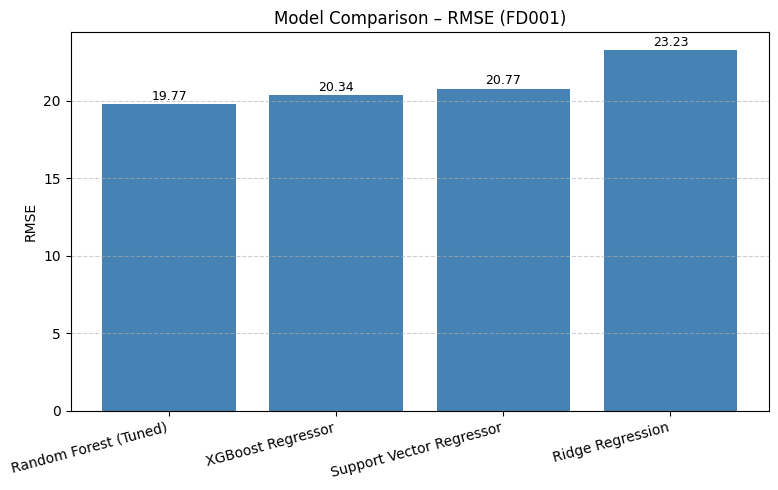

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Bar Plot for RMSE
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results['Model'], model_results['RMSE'], color='steelblue')
plt.title("Model Comparison – RMSE (FD001)")
plt.ylabel("RMSE")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

# Save chart
comparison_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'model_comparison_rmse_fd001.png'))
plt.tight_layout()
plt.savefig(comparison_path)
print(f"\nModel comparison chart saved to: {comparison_path}")
plt.show()


---
# Step 8: Residual Analysis – Ensemble and Individual Models (FD001)
Residual analysis provides insights into systematic biases and prediction reliability.

Residual = Actual - Predicted

This analysis helps to identify:

Whether the model is overestimating or underestimating.

If variance increases with prediction magnitude (heteroscedasticity).

### Step 8A: Import Required Libraries


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


### Step 8B: Compute Residuals for All Models


In [39]:
# Compute residuals: y_true - y_pred
residuals = {
    "Random Forest": y_test - y_pred_rf,
    "Ridge Regression": y_test - y_pred_ridge,
    "SVR": y_test - y_pred_svr,
    "XGBoost": y_test - y_pred_xgb
}


### Step 8C: Plot Residuals Distribution


 Saved residual distribution plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_distribution_fd001.png


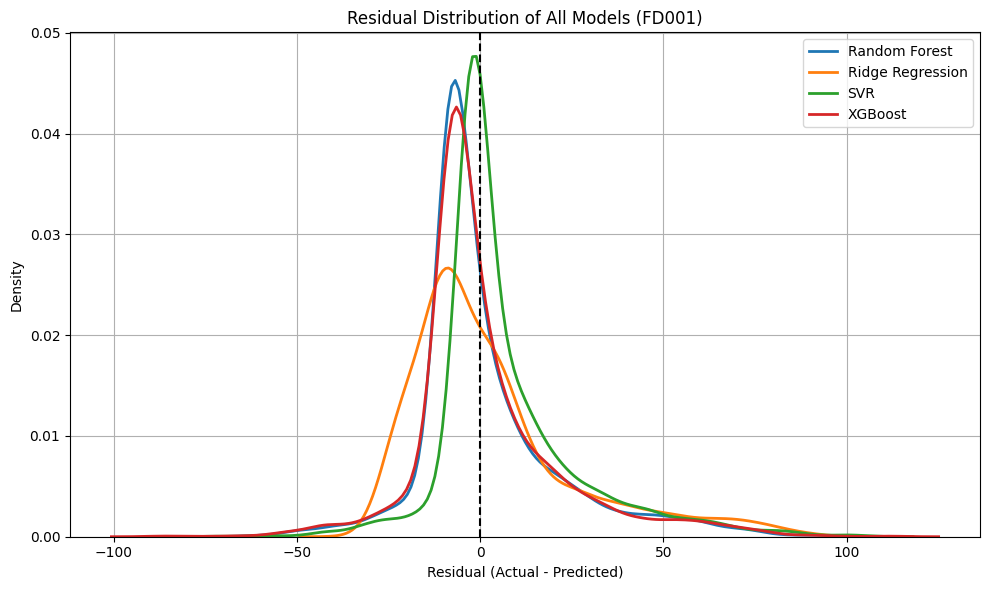

In [40]:
plt.figure(figsize=(10, 6))
for name, res in residuals.items():
    sns.kdeplot(res, label=name, linewidth=2)

plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Distribution of All Models (FD001)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_distribution_fd001.png'))
plt.savefig(fig_path)
print(f" Saved residual distribution plot to: {fig_path}")
plt.show()


### Step 8D: Residuals vs Predicted Plot for Key Models


 Saved residual vs predicted plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_vs_predicted_fd001.png


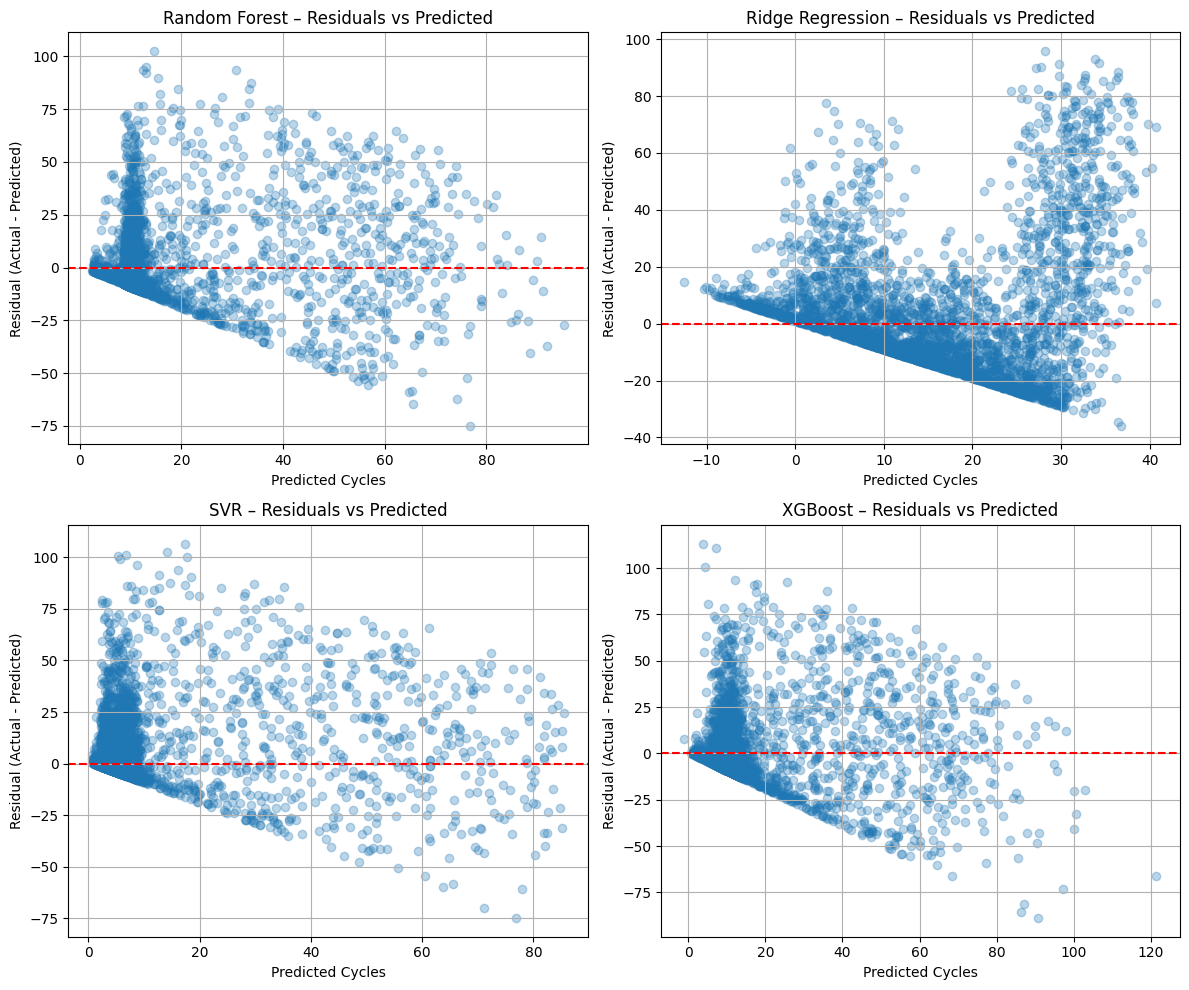

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
model_preds = {
    "Random Forest": y_pred_rf,
    "Ridge Regression": y_pred_ridge,
    "SVR": y_pred_svr,
    "XGBoost": y_pred_xgb
}

for ax, (name, pred) in zip(axes.flatten(), model_preds.items()):
    ax.scatter(pred, residuals[name], alpha=0.3)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f"{name} – Residuals vs Predicted")
    ax.set_xlabel("Predicted Cycles")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.grid(True)

plt.tight_layout()
fig_path2 = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_vs_predicted_fd001.png'))
plt.savefig(fig_path2)
print(f" Saved residual vs predicted plot to: {fig_path2}")
plt.show()


---

# Step 9: Ensemble Averaging – FD001


### Step 9A: Import Required Libraries


In [42]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

### Step 9B: Average Predictions from All Models


In [43]:
# Ensure predictions from all trained models are already available
# y_pred_rf, y_pred_ridge, y_pred_svr, y_pred_xgb should all exist
y_pred_ensemble = (
    y_pred_rf +
    y_pred_ridge +
    y_pred_svr +
    y_pred_xgb
) / 4.0


### Step 9C: Evaluate Ensemble Performance


In [44]:
# Ensemble evaluation metrics
rmse_ens = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
mae_ens = mean_absolute_error(y_test, y_pred_ensemble)
r2_ens = r2_score(y_test, y_pred_ensemble)

print(" Ensemble Averaging Evaluation (FD001):")
print(f" RMSE: {rmse_ens:.2f}")
print(f" MAE : {mae_ens:.2f}")
print(f" R²  : {r2_ens:.4f}")


 Ensemble Averaging Evaluation (FD001):
 RMSE: 20.15
 MAE : 13.32
 R²  : 0.4193


### Step 9D: Visualization – Predicted vs Actual


 Saved ensemble prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ensemble_pred_vs_actual_fd001.png


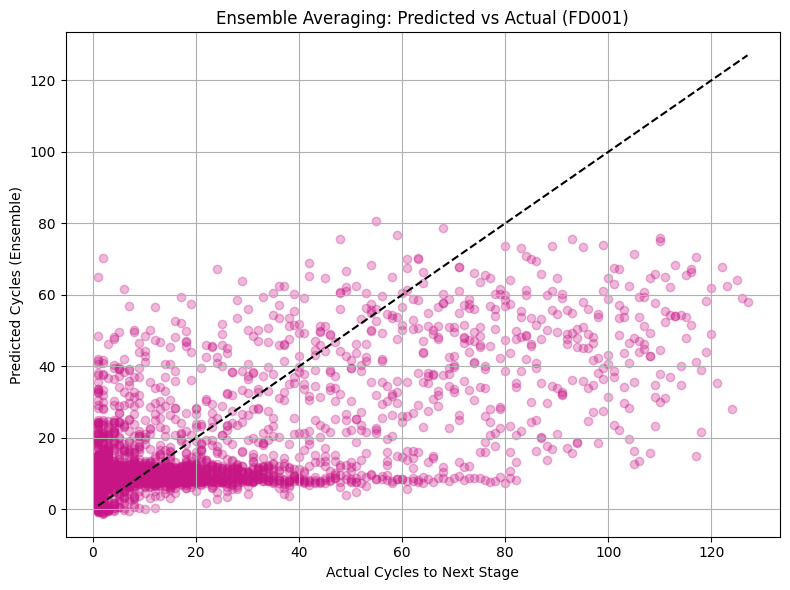

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ensemble, alpha=0.3, color='mediumvioletred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles (Ensemble)")
plt.title("Ensemble Averaging: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ensemble_pred_vs_actual_fd001.png'))
plt.savefig(fig_path)
print(f" Saved ensemble prediction plot to: {fig_path}")
plt.show()


---

# Step 10 – Residual Analysis for Ensemble Averaging (FD001)


### Step 10A: Residual Distribution Plot – Ensemble Averaging


Residual distribution plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_distribution_ensemble_fd001.png


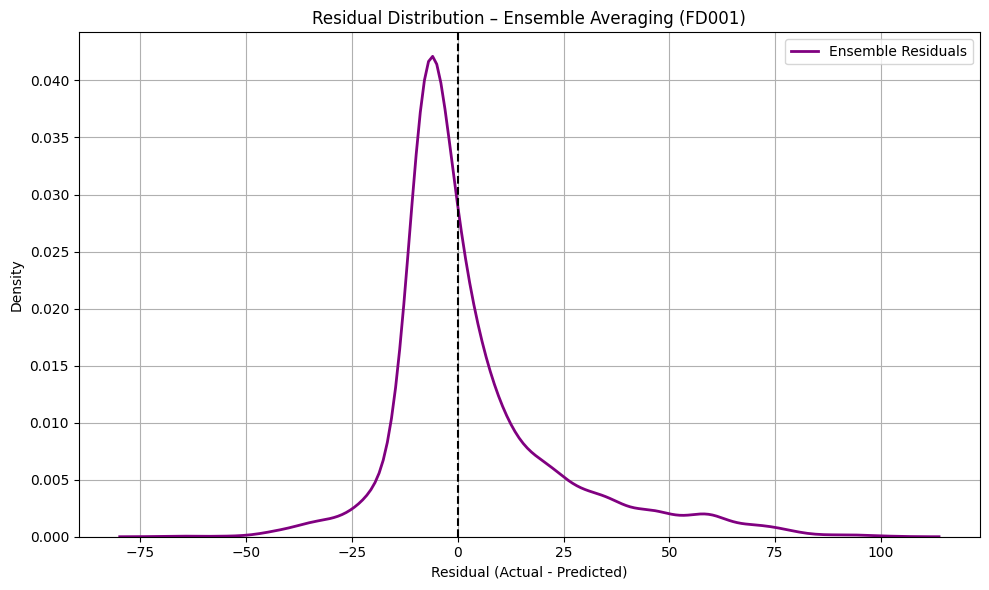

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Calculate residuals
residuals_ensemble = y_test - y_pred_ensemble

# Plot residual distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(residuals_ensemble, color='purple', linewidth=2, label="Ensemble Residuals")
plt.axvline(0, linestyle='--', color='black')
plt.title("Residual Distribution – Ensemble Averaging (FD001)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_distribution_ensemble_fd001.png'))
plt.savefig(fig_path)
print(f"Residual distribution plot saved to: {fig_path}")
plt.show()


### Step 10B: Residuals vs Predicted Plot – Ensemble Averaging


Residual vs predicted plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_vs_predicted_ensemble_fd001.png


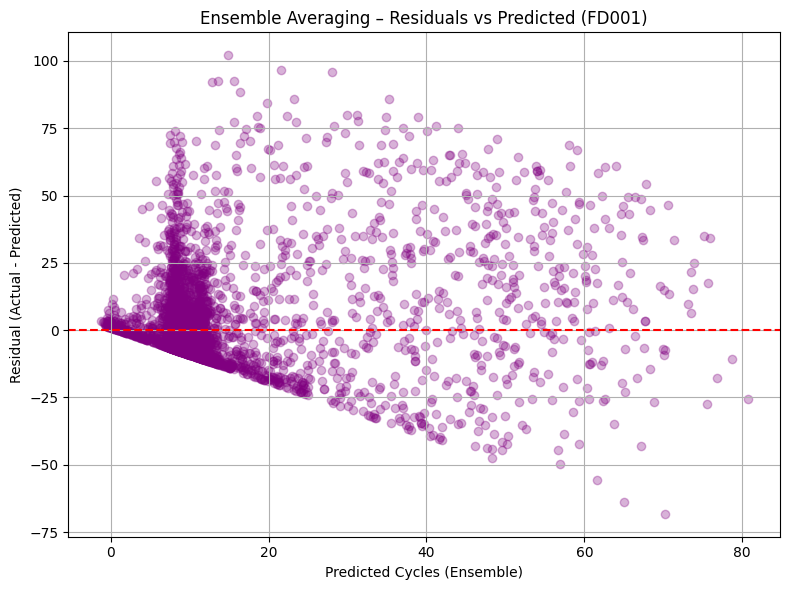

In [47]:
# Plot residuals vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_ensemble, residuals_ensemble, alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Cycles (Ensemble)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Ensemble Averaging – Residuals vs Predicted (FD001)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path2 = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_vs_predicted_ensemble_fd001.png'))
plt.savefig(fig_path2)
print(f"Residual vs predicted plot saved to: {fig_path2}")
plt.show()


---
# FD001 – Save Final Predictions + Ensemble Outputs

In [50]:
import os
import pandas as pd

# Set correct save path
save_path_fd001 = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
os.makedirs(save_path_fd001, exist_ok=True)

# Construct DataFrame with all outputs
final_df_fd001 = pd.DataFrame({
    'unit': test_df['unit'],
    'time': test_df['time'],
    'actual_cycles_to_next_stage': y_test,
    'random_forest_prediction': y_pred_rf,
    'ridge_prediction': y_pred_ridge,
    'svr_prediction': y_pred_svr,
    'xgboost_prediction': y_pred_xgb,
    'ensemble_prediction': y_pred_ensemble
})

# Save to CSV
fd001_csv_path = os.path.join(save_path_fd001, 'final_predictions_fd001.csv')
final_df_fd001.to_csv(fd001_csv_path, index=False)

print(f"FD001 predictions saved to: {fd001_csv_path}")


FD001 predictions saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\final_predictions_fd001.csv
